# Cardinality-Controlled LLM-Judge Alignment

This notebook computes macro-averaged alignment metrics from the finalized LLM-judge matching tables. Each metric is computed at the `screen_task_id` level first and then averaged across screen-task instances. NLP-based validation analyses are intentionally excluded.

In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "analysis" else Path.cwd().resolve()
RUN_LABEL = "zero_shot-all_tasks"

MODEL_ORDER = ["claude4_7", "gpt5", "gemini3_1pro"]
MODEL_DISPLAY = {
    "claude4_7": "Claude Opus 4.7",
    "gpt5": "GPT-5",
    "gemini3_1pro": "Gemini 3.1 Pro",
}
MODEL_COLORS = {
    "claude4_7": "#F58518",
    "gpt5": "#4C78A8",
    "gemini3_1pro": "#54A24B",
}
K_VALUES = [1, 3, 5]
BOOTSTRAP_ITERATIONS = 1000
RANDOM_SEED = 42

RESULTS_DIR = PROJECT_ROOT / "code" / "results" / "critiques" / "cardinality_controlled_alignment_macro"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Load Matching Tables

In [4]:
RELATION_WEIGHTS = {
    "equivalent": 1.00,
    "llm_broader": 0.85,
    "human_broader": 0.85,
    "partial_overlap": 0.50,
    "related_but_different": 0.00,
    "no_match": 0.00,
    "contradiction": 0.00,
}

RELATION_NORMALIZATION = {
    "equivalent": "equivalent",
    "A_broader": "human_broader",
    "B_broader": "llm_broader",
    "partial_overlap": "partial_overlap",
    "related_but_different": "related_but_different",
    "no_match": "no_match",
    "contradiction": "contradiction",
}

REQUIRED_COLUMNS = {
    "pair_id",
    "screen_task_id",
    "expert_comment_id",
    "llm_comment_id",
    "expert_observed_issue",
    "llm_observed_issue",
    "relation",
    "confidence",
}

human_tasks = (
    pd.read_parquet(PROJECT_ROOT / "data" / "dataset" / "cleaned_dataset" / "human_comments_semantic_dedup.parquet")
    [["screen_task_id", "app", "app_category"]]
    .rename(columns={"app": "app_name"})
    .drop_duplicates("screen_task_id")
)

frames = []
for model in MODEL_ORDER:
    path = (
        PROJECT_ROOT
        / "code"
        / "results"
        / "critiques"
        / "matching"
        / model
        / RUN_LABEL
        / "llmjudge_matching"
        / f"llmjudge_matching_pairs-{RUN_LABEL}-{model}.parquet"
    )
    df = pd.read_parquet(path)
    missing = REQUIRED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")

    df = df.assign(
        model_short=model,
        model_name=MODEL_DISPLAY[model],
        relation_canonical=df["relation"].map(RELATION_NORMALIZATION),
    )
    bad_relations = sorted(df.loc[df["relation_canonical"].isna(), "relation"].dropna().unique())
    if bad_relations:
        raise ValueError(f"Unmapped relation labels for {model}: {bad_relations}")

    df["relation_weight"] = df["relation_canonical"].map(RELATION_WEIGHTS).astype(float)
    frames.append(df.merge(human_tasks, on="screen_task_id", how="left"))

pairs = pd.concat(frames, ignore_index=True)

# Preserve the original generated-comment order through first appearance in the pair table.
llm_order = (
    pairs[["model_short", "screen_task_id", "llm_comment_id"]]
    .drop_duplicates()
    .assign(llm_position=lambda x: x.groupby(["model_short", "screen_task_id"]).cumcount() + 1)
)
pairs = pairs.merge(llm_order, on=["model_short", "screen_task_id", "llm_comment_id"], how="left")

load_summary = (
    pairs.groupby(["model_short", "model_name"], sort=False)
    .agg(
        pair_rows=("pair_id", "size"),
        screen_tasks=("screen_task_id", "nunique"),
        expert_comments=("expert_comment_id", "nunique"),
        llm_comments=("llm_comment_id", "nunique"),
        apps=("app_name", "nunique"),
    )
    .reset_index()
)
load_summary.to_csv(TABLES_DIR / "input_matching_table_summary.csv", index=False)
load_summary

,model_short,model_name,pair_rows,screen_tasks,expert_comments,llm_comments,apps
0,claude4_7,Claude Opus 4.7,72285,2952,10493,20160,871
1,gpt5,GPT-5,64255,2950,10488,17892,871
2,gemini3_1pro,Gemini 3.1 Pro,36015,2952,10493,9981,871


## 2. Macro-Averaged Unconstrained and Bipartite Metrics


In [5]:
def _assignment_scores(weights: np.ndarray, expert_count: int, llm_count: int) -> tuple[float, float, float]:
    if expert_count == 0 or llm_count == 0:
        return np.nan, np.nan, 0.0
    row_ind, col_ind = linear_sum_assignment(-weights)
    matched_sum = float(weights[row_ind, col_ind].sum())
    return matched_sum / expert_count, matched_sum / llm_count, matched_sum


def _weighted_matrix(screen_pairs: pd.DataFrame) -> pd.DataFrame:
    llm_ordered = (
        screen_pairs[["llm_comment_id", "llm_position"]]
        .drop_duplicates()
        .sort_values("llm_position")["llm_comment_id"]
        .tolist()
    )
    return screen_pairs.pivot_table(
        index="expert_comment_id",
        columns="llm_comment_id",
        values="relation_weight",
        aggfunc="max",
        fill_value=0.0,
    ).reindex(columns=llm_ordered, fill_value=0.0)


screen_rows = []
k_screen_rows = []
group_cols = ["model_short", "model_name", "app_name", "app_category", "screen_task_id"]

for keys, screen_pairs in pairs.groupby(group_cols, sort=False):
    key_values = dict(zip(group_cols, keys))
    matrix = _weighted_matrix(screen_pairs)
    weights = matrix.to_numpy(dtype=float)
    expert_count, llm_count = matrix.shape

    bip_cov, bip_sup, matched_sum = _assignment_scores(weights, expert_count, llm_count)
    screen_rows.append({
        **key_values,
        "unconstrained_expert_coverage": float(weights.max(axis=1).mean()) if expert_count else np.nan,
        "unconstrained_reference_support": float(weights.max(axis=0).mean()) if llm_count else np.nan,
        "bipartite_expert_coverage": bip_cov,
        "bipartite_reference_support": bip_sup,
        "matched_weight_sum": matched_sum,
        "expert_comments": expert_count,
        "llm_comments": llm_count,
    })

    positions = (
        screen_pairs[["llm_comment_id", "llm_position"]]
        .drop_duplicates()
        .set_index("llm_comment_id")
        .loc[matrix.columns, "llm_position"]
        .to_numpy()
    )
    for k in K_VALUES:
        keep = positions <= k
        k_weights = weights[:, keep]
        k_llm_count = int(keep.sum())
        k_cov, k_sup, _ = _assignment_scores(k_weights, expert_count, k_llm_count)
        k_screen_rows.append({
            **key_values,
            "k": k,
            "bipartite_expert_coverage": k_cov,
            "bipartite_reference_support": k_sup,
        })

screen_metrics = pd.DataFrame(screen_rows)
k_screen_metrics = pd.DataFrame(k_screen_rows)

core_metric_cols = [
    "unconstrained_expert_coverage",
    "unconstrained_reference_support",
    "bipartite_expert_coverage",
    "bipartite_reference_support",
]
core_metrics = (
    screen_metrics.groupby(["model_short", "model_name"], sort=False)[core_metric_cols]
    .mean()
    .reset_index()
    .assign(averaging="macro_screen")
)
core_metrics_pct = core_metrics.rename(columns={metric: f"{metric}_pct" for metric in core_metric_cols}).copy()
core_metrics_pct[[f"{metric}_pct" for metric in core_metric_cols]] *= 100
core_metrics_pct.round(1).to_csv(TABLES_DIR / "macro_core_alignment_metrics.csv", index=False, float_format="%.1f")
screen_metrics.round(2).to_parquet(TABLES_DIR / "screen_level_alignment_metrics.parquet", index=False)
core_metrics_pct.round(1)


,model_short,model_name,unconstrained_expert_coverage_pct,unconstrained_reference_support_pct,bipartite_expert_coverage_pct,bipartite_reference_support_pct,averaging
0,claude4_7,Claude Opus 4.7,25.1,12.3,23.6,11.4,macro_screen
1,gpt5,GPT-5,23.1,12.6,21.4,11.8,macro_screen
2,gemini3_1pro,Gemini 3.1 Pro,20.6,19.1,18.9,18.3,macro_screen


## 3. Clustered App-Level Bootstrap Confidence Intervals


In [6]:
def bootstrap_macro_ci(
    screen_df: pd.DataFrame,
    metric_cols: list[str],
    *,
    group_cols: list[str] | None = None,
    iterations: int = BOOTSTRAP_ITERATIONS,
    seed: int = RANDOM_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    group_cols = group_cols or []
    rows, draws = [], []

    for keys, model_df in screen_df.groupby(["model_short", "model_name", *group_cols], sort=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(["model_short", "model_name", *group_cols], keys))

        app_names = model_df["app_name"].dropna().unique()
        by_app = {app: app_df[metric_cols].to_numpy(dtype=float) for app, app_df in model_df.groupby("app_name", sort=False)}
        boot_values = np.empty((iterations, len(metric_cols)), dtype=float)

        for i in range(iterations):
            sampled_apps = rng.choice(app_names, size=len(app_names), replace=True)
            sampled = np.vstack([by_app[app] for app in sampled_apps])
            boot_values[i] = np.nanmean(sampled, axis=0)

        for j, metric in enumerate(metric_cols):
            point = float(model_df[metric].mean())
            low, high = np.percentile(boot_values[:, j], [2.5, 97.5])
            rows.append({
                **key_dict,
                "metric": metric,
                "point_estimate": point,
                "ci_low": float(low),
                "ci_high": float(high),
                "bootstrap_iterations": iterations,
            })

        draw_base = pd.DataFrame(boot_values, columns=metric_cols).assign(iteration=np.arange(iterations), **key_dict)
        draws.append(draw_base)

    return pd.DataFrame(rows), pd.concat(draws, ignore_index=True)


core_ci, core_bootstrap_draws = bootstrap_macro_ci(screen_metrics, core_metric_cols)

core_ci_pct = core_ci.rename(columns={"point_estimate": "point_estimate_pct", "ci_low": "ci_low_pct", "ci_high": "ci_high_pct"}).copy()
core_ci_pct[["point_estimate_pct", "ci_low_pct", "ci_high_pct"]] *= 100
core_ci_pct.round(1).to_csv(TABLES_DIR / "macro_core_alignment_bootstrap_ci.csv", index=False, float_format="%.1f")
core_bootstrap_draws.round(2).to_parquet(TABLES_DIR / "macro_core_alignment_bootstrap_draws.parquet", index=False)
core_ci_pct.round(1)


,model_short,model_name,metric,point_estimate_pct,ci_low_pct,ci_high_pct,bootstrap_iterations
0,claude4_7,Claude Opus 4.7,unconstrained_expert_coverage,25.1,23.9,26.2,1000
1,claude4_7,Claude Opus 4.7,unconstrained_reference_support,12.3,11.8,12.9,1000
2,claude4_7,Claude Opus 4.7,bipartite_expert_coverage,23.6,22.5,24.6,1000
3,claude4_7,Claude Opus 4.7,bipartite_reference_support,11.4,10.9,11.9,1000
4,gpt5,GPT-5,unconstrained_expert_coverage,23.1,22.0,24.2,1000
5,gpt5,GPT-5,unconstrained_reference_support,12.6,12.0,13.2,1000
6,gpt5,GPT-5,bipartite_expert_coverage,21.4,20.4,22.3,1000
7,gpt5,GPT-5,bipartite_reference_support,11.8,11.3,12.4,1000
8,gemini3_1pro,Gemini 3.1 Pro,unconstrained_expert_coverage,20.6,19.6,21.6,1000
9,gemini3_1pro,Gemini 3.1 Pro,unconstrained_reference_support,19.1,18.1,19.9,1000


## 4. Fixed-K Bipartite Budget Control

At each threshold $K$, bipartite expert coverage and reference support are recomputed using only the first $K$ generated critiques for each screen--task instance.

In [7]:
fixed_k_metrics = (
    k_screen_metrics.groupby(["model_short", "model_name", "k"], sort=False)[
        ["bipartite_expert_coverage", "bipartite_reference_support"]
    ]
    .mean()
    .reset_index()
)

k_screen_metrics.round(2).to_parquet(TABLES_DIR / "fixed_k_screen_level_bipartite_metrics.parquet", index=False)
fixed_k_metric_cols = ["bipartite_expert_coverage", "bipartite_reference_support"]
fixed_k_metrics_pct = fixed_k_metrics.rename(columns={metric: f"{metric}_pct" for metric in fixed_k_metric_cols}).copy()
fixed_k_metrics_pct[[f"{metric}_pct" for metric in fixed_k_metric_cols]] *= 100
fixed_k_metrics_pct.round(1).to_csv(TABLES_DIR / "fixed_k_macro_bipartite_metrics.csv", index=False, float_format="%.1f")
fixed_k_metrics_pct.round(1)

,model_short,model_name,k,bipartite_expert_coverage_pct,bipartite_reference_support_pct
0,claude4_7,Claude Opus 4.7,1,5.4,16.6
1,claude4_7,Claude Opus 4.7,3,12.8,13.3
2,claude4_7,Claude Opus 4.7,5,18.6,11.9
3,gpt5,GPT-5,1,5.0,15.2
4,gpt5,GPT-5,3,12.4,13.1
5,gpt5,GPT-5,5,18.1,12.3
6,gemini3_1pro,Gemini 3.1 Pro,1,7.4,22.6
7,gemini3_1pro,Gemini 3.1 Pro,3,16.9,18.7
8,gemini3_1pro,Gemini 3.1 Pro,5,18.9,18.3


## 5. Visualizations


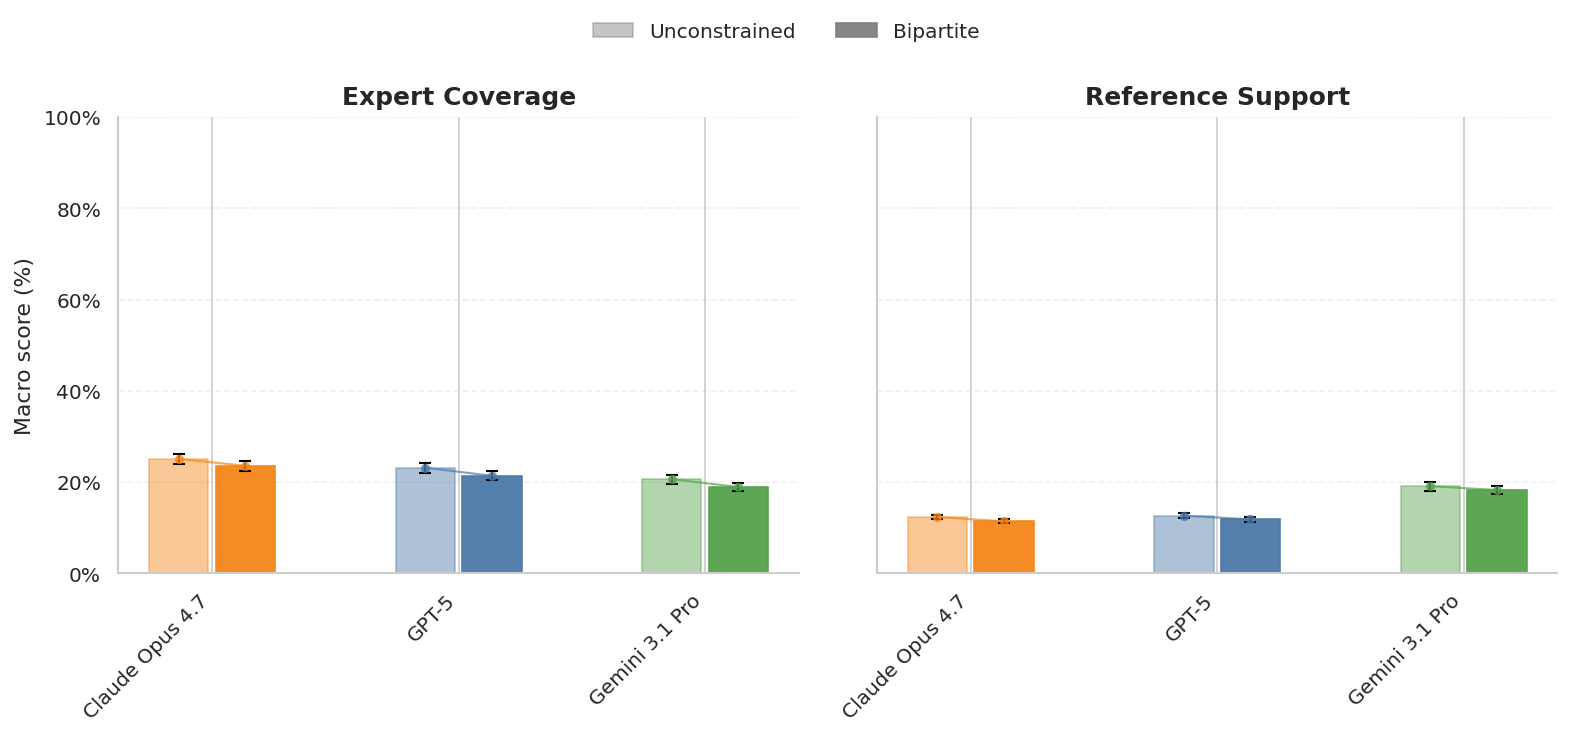

In [8]:
core_metric_groups = {
    "Expert Coverage": {
        "unconstrained": "unconstrained_expert_coverage",
        "bipartite": "bipartite_expert_coverage",
    },
    "Reference Support": {
        "unconstrained": "unconstrained_reference_support",
        "bipartite": "bipartite_reference_support",
    },
}
method_labels = {"unconstrained": "Unconstrained", "bipartite": "Bipartite"}
method_alpha = {"unconstrained": 0.45, "bipartite": 0.95}

bar_width = 0.24
gap_within_model = 0.03
x_centers = np.arange(len(MODEL_ORDER), dtype=float)
method_offsets = {
    "unconstrained": -(bar_width + gap_within_model) / 2,
    "bipartite": (bar_width + gap_within_model) / 2,
}

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.8), sharey=True)

for ax, (panel_title, metrics) in zip(axes, core_metric_groups.items()):
    for model_idx, model in enumerate(MODEL_ORDER):
        color = MODEL_COLORS[model]
        model_rows = core_ci[core_ci["model_short"].eq(model)].set_index("metric")

        for method, metric in metrics.items():
            row = model_rows.loc[metric]
            x = x_centers[model_idx] + method_offsets[method]
            y = row["point_estimate"]
            ax.bar(
                x,
                y,
                width=bar_width,
                color=color,
                alpha=method_alpha[method],
                edgecolor=color,
                linewidth=0.8,
            )
            ax.errorbar(
                x,
                y,
                yerr=[[y - row["ci_low"]], [row["ci_high"] - y]],
                fmt="none",
                color="black",
                capsize=3,
                linewidth=1,
            )

        ax.plot(
            [x_centers[model_idx] + method_offsets[m] for m in method_labels],
            [model_rows.loc[metrics[m], "point_estimate"] for m in method_labels],
            marker="o",
            markersize=3.5,
            color=color,
            alpha=0.7,
            linewidth=1,
        )

    ax.set_title(panel_title, fontsize=12, weight="bold")
    ax.set_xticks(x_centers)
    ax.set_xticklabels([MODEL_DISPLAY[model] for model in MODEL_ORDER], rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Macro score (%)")
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
axes[0].set_ylim(0, 1)
fig.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color="gray", alpha=method_alpha[m], label=method_labels[m]) for m in method_labels],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES_DIR / "macro_core_alignment_metrics_barplot.png")
plt.show()


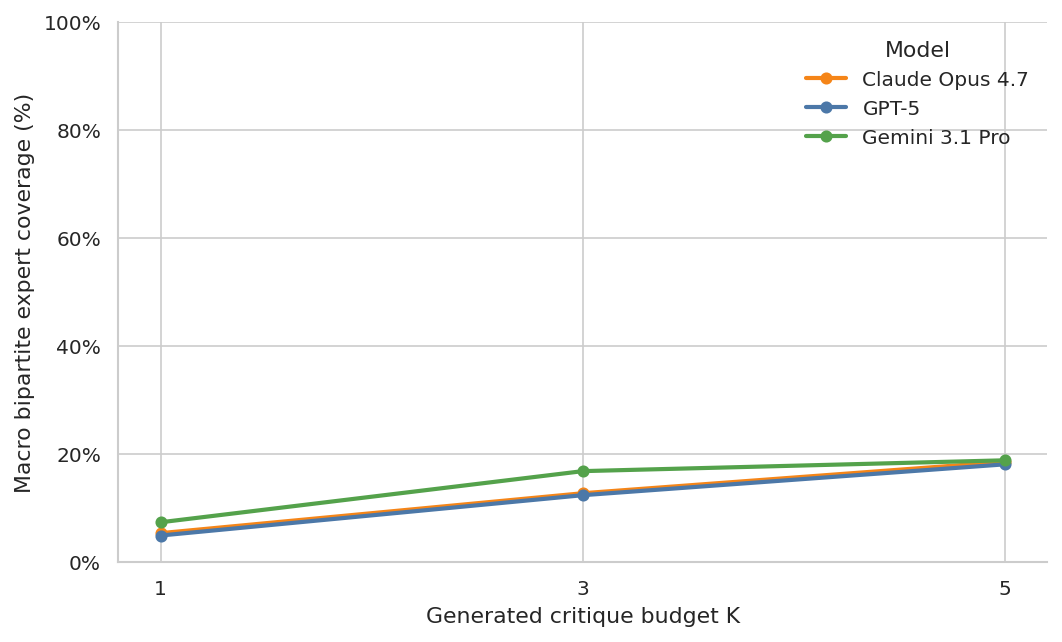

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for model in MODEL_ORDER:
    model_line = fixed_k_metrics[fixed_k_metrics["model_short"].eq(model)].sort_values("k")
    ax.plot(
        model_line["k"],
        model_line["bipartite_expert_coverage"],
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model],
        label=MODEL_DISPLAY[model],
    )
ax.set_xlabel("Generated critique budget K")
ax.set_ylabel("Macro bipartite expert coverage (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_xticks(K_VALUES)
ax.set_ylim(0, 1)
ax.legend(title="Model", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fixed_k_bipartite_expert_coverage.png")
plt.show()

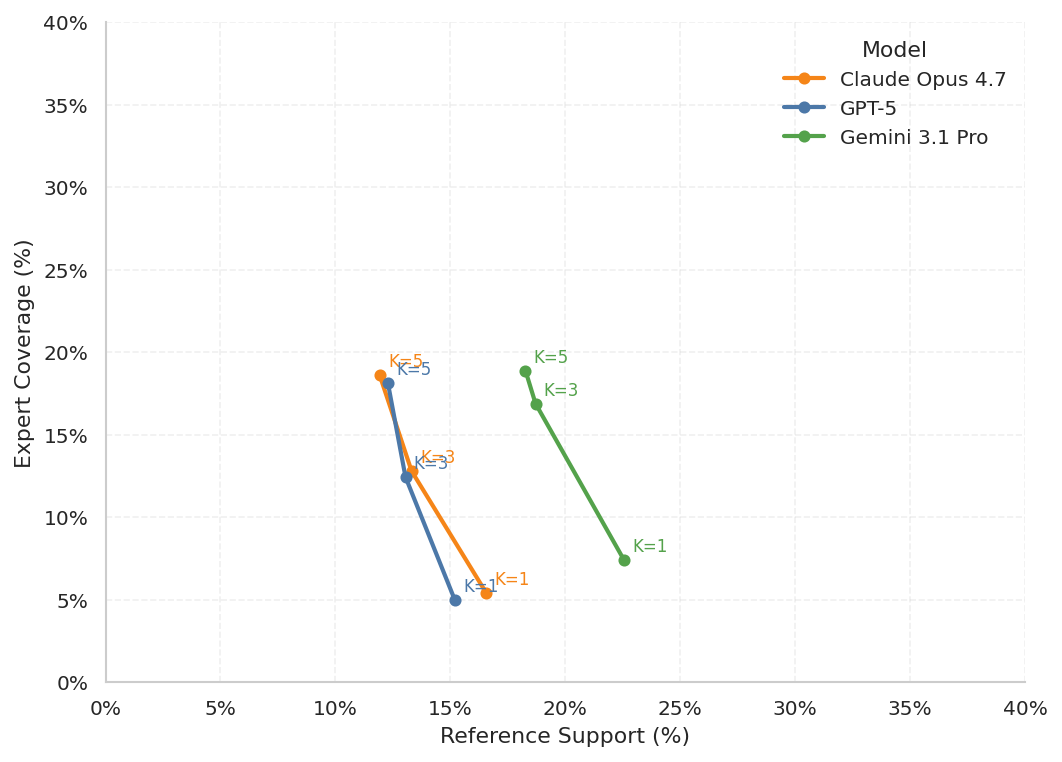

,model_short,model_name,k,bipartite_expert_coverage,bipartite_reference_support
0,claude4_7,Claude Opus 4.7,1,0.054,0.166
1,claude4_7,Claude Opus 4.7,3,0.128,0.133
2,claude4_7,Claude Opus 4.7,5,0.186,0.119
3,gpt5,GPT-5,1,0.050,0.152
4,gpt5,GPT-5,3,0.124,0.131
5,gpt5,GPT-5,5,0.181,0.123
6,gemini3_1pro,Gemini 3.1 Pro,1,0.074,0.226
7,gemini3_1pro,Gemini 3.1 Pro,3,0.169,0.187
8,gemini3_1pro,Gemini 3.1 Pro,5,0.189,0.183


In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
for model in MODEL_ORDER:
    model_line = fixed_k_metrics[fixed_k_metrics["model_short"].eq(model)].sort_values("k")
    ax.plot(
        model_line["bipartite_reference_support"],
        model_line["bipartite_expert_coverage"],
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model],
        label=MODEL_DISPLAY[model],
    )
    for row in model_line.itertuples(index=False):
        ax.annotate(
            f"K={row.k}",
            (row.bipartite_reference_support, row.bipartite_expert_coverage),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            color=MODEL_COLORS[model],
        )
ax.set_xlabel("Reference Support (%)")
ax.set_ylabel("Expert Coverage (%)")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_xlim(0, 0.4)
ax.set_ylim(0, 0.4)
ax.grid(linestyle="--", alpha=0.3)
ax.legend(title="Model", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fixed_k_bipartite_coverage_vs_support.png")
plt.show()

## 6. Contradiction Analysis


In [11]:
contradiction_summary = (
    pairs.groupby(["model_short", "model_name"], sort=False)
    .apply(
        lambda g: pd.Series({
            "llm_comments": g["llm_comment_id"].nunique(),
            "contradiction_pairs": int(g["relation_canonical"].eq("contradiction").sum()),
            "llm_comments_with_contradiction": g.loc[g["relation_canonical"].eq("contradiction"), "llm_comment_id"].nunique(),
        }),
        include_groups=False,
    )
    .reset_index()
)
contradiction_summary["contradiction_llm_comment_rate_pct"] = 100 * (
    contradiction_summary["llm_comments_with_contradiction"] / contradiction_summary["llm_comments"]
)
contradiction_summary.round(2).to_csv(TABLES_DIR / "contradiction_summary.csv", index=False, float_format="%.2f")
contradiction_summary.round(2)

,model_short,model_name,llm_comments,contradiction_pairs,llm_comments_with_contradiction,contradiction_llm_comment_rate_pct
0,claude4_7,Claude Opus 4.7,20160,49,47,0.23
1,gpt5,GPT-5,17892,48,48,0.27
2,gemini3_1pro,Gemini 3.1 Pro,9981,18,18,0.18


## 7. Generate Manual Audit Samples

Generate CSV exports for human reviewers to audit additional LLM findings, unmatched expert comments, and true contradictions.


In [12]:
MANUAL_AUDIT_SAMPLE_SIZE = 50


def _sample_stratified_by_category(
    df: pd.DataFrame,
    *,
    n: int = MANUAL_AUDIT_SAMPLE_SIZE,
    strata_col: str = "app_category",
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    if len(df) <= n:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    counts = df[strata_col].fillna("Missing").value_counts(sort=False)
    raw_alloc = counts / counts.sum() * n
    alloc = np.floor(raw_alloc).astype(int)

    positive_strata = counts[counts > 0].index
    alloc.loc[(alloc == 0) & alloc.index.isin(positive_strata)] = 1
    alloc = np.minimum(alloc, counts)

    while alloc.sum() > n:
        reducible = alloc[alloc > 1]
        idx = (raw_alloc.loc[reducible.index] - alloc.loc[reducible.index]).idxmin()
        alloc.loc[idx] -= 1

    while alloc.sum() < n:
        capacity = counts - alloc
        eligible = capacity[capacity > 0]
        if eligible.empty:
            break
        idx = (raw_alloc.loc[eligible.index] - alloc.loc[eligible.index]).idxmax()
        alloc.loc[idx] += 1

    sampled = []
    for category, take in alloc.items():
        if take <= 0:
            continue
        category_rows = df[df[strata_col].fillna("Missing").eq(category)]
        sampled.append(category_rows.sample(n=int(take), random_state=seed))

    return pd.concat(sampled, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def _bipartite_comment_weights(screen_pairs: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    non_contradictions = screen_pairs[~screen_pairs["relation_canonical"].eq("contradiction")]
    expert_ids = screen_pairs["expert_comment_id"].drop_duplicates().tolist()
    llm_ids = (
        screen_pairs[["llm_comment_id", "llm_position"]]
        .drop_duplicates()
        .sort_values("llm_position")["llm_comment_id"]
        .tolist()
    )
    matrix = pd.DataFrame(0.0, index=expert_ids, columns=llm_ids)
    if not non_contradictions.empty:
        observed_weights = _weighted_matrix(non_contradictions).reindex(index=expert_ids, columns=llm_ids, fill_value=0.0)
        matrix = observed_weights.combine_first(matrix).fillna(0.0)
    weights = matrix.to_numpy(dtype=float)

    expert_weights = pd.Series(0.0, index=matrix.index, name="bipartite_match_weight")
    llm_weights = pd.Series(0.0, index=matrix.columns, name="bipartite_match_weight")

    if matrix.shape[0] > 0 and matrix.shape[1] > 0:
        row_ind, col_ind = linear_sum_assignment(-weights)
        assigned_weights = weights[row_ind, col_ind]
        expert_weights.iloc[row_ind] = assigned_weights
        llm_weights.iloc[col_ind] = assigned_weights

    expert_meta = (
        screen_pairs[["model_short", "model_name", "screen_task_id", "app_category", "expert_comment_id", "expert_observed_issue"]]
        .drop_duplicates("expert_comment_id")
        .set_index("expert_comment_id")
    )
    llm_meta = (
        screen_pairs[["model_short", "model_name", "screen_task_id", "app_category", "llm_comment_id", "llm_observed_issue"]]
        .drop_duplicates("llm_comment_id")
        .set_index("llm_comment_id")
    )

    expert_audit = expert_meta.join(expert_weights, how="inner").reset_index()
    llm_audit = llm_meta.join(llm_weights, how="inner").reset_index()
    return expert_audit, llm_audit


expert_weight_rows = []
llm_weight_rows = []
for _, screen_pairs in pairs.groupby(["model_short", "screen_task_id"], sort=False):
    expert_audit, llm_audit = _bipartite_comment_weights(screen_pairs)
    expert_weight_rows.append(expert_audit)
    llm_weight_rows.append(llm_audit)

expert_bipartite_weights = pd.concat(expert_weight_rows, ignore_index=True)
llm_bipartite_weights = pd.concat(llm_weight_rows, ignore_index=True)

unmatched_llm_candidates = llm_bipartite_weights[llm_bipartite_weights["bipartite_match_weight"].eq(0.0)].copy()
unmatched_expert_candidates = expert_bipartite_weights[expert_bipartite_weights["bipartite_match_weight"].eq(0.0)].copy()

unmatched_llm_audit_sample = pd.concat(
    [
        _sample_stratified_by_category(group, seed=RANDOM_SEED)
        for _, group in unmatched_llm_candidates.groupby(["model_short", "model_name"], sort=False)
    ],
    ignore_index=True,
)
unmatched_llm_audit_sample["audit_label"] = ""
unmatched_llm_audit_sample = unmatched_llm_audit_sample[
    ["model_short", "model_name", "screen_task_id", "app_category", "llm_observed_issue", "audit_label"]
]

unmatched_expert_audit_sample = pd.concat(
    [
        _sample_stratified_by_category(group, seed=RANDOM_SEED)
        for _, group in unmatched_expert_candidates.groupby(["model_short", "model_name"], sort=False)
    ],
    ignore_index=True,
)
unmatched_expert_audit_sample["audit_label"] = ""
unmatched_expert_audit_sample = unmatched_expert_audit_sample[
    ["model_short", "model_name", "screen_task_id", "app_category", "expert_observed_issue", "audit_label"]
]

contradiction_audit_export = pairs[pairs["relation_canonical"].eq("contradiction")].copy()
contradiction_audit_export["audit_label"] = ""
contradiction_audit_export = contradiction_audit_export[
    [
        "model_short",
        "model_name",
        "screen_task_id",
        "app_category",
        "expert_observed_issue",
        "llm_observed_issue",
        "audit_label",
    ]
]

unmatched_llm_audit_sample.to_csv(TABLES_DIR / "manual_audit_unmatched_llm_sample.csv", index=False)
unmatched_expert_audit_sample.to_csv(TABLES_DIR / "manual_audit_unmatched_expert_sample.csv", index=False)
contradiction_audit_export.to_csv(TABLES_DIR / "manual_audit_contradiction_pairs.csv", index=False)

manual_audit_summary = pd.DataFrame(
    [
        {
            "audit_export": "manual_audit_unmatched_llm_sample",
            "rows": len(unmatched_llm_audit_sample),
            "sampling": f"up to {MANUAL_AUDIT_SAMPLE_SIZE} rows per model, stratified by app_category",
        },
        {
            "audit_export": "manual_audit_unmatched_expert_sample",
            "rows": len(unmatched_expert_audit_sample),
            "sampling": f"up to {MANUAL_AUDIT_SAMPLE_SIZE} rows per model, stratified by app_category",
        },
        {
            "audit_export": "manual_audit_contradiction_pairs",
            "rows": len(contradiction_audit_export),
            "sampling": "all contradiction pairs",
        },
    ]
)
manual_audit_summary.to_csv(TABLES_DIR / "manual_audit_export_summary.csv", index=False)
manual_audit_summary


KeyboardInterrupt: 

## 8. Export Manifest


In [ ]:
manifest = pd.DataFrame(
    [
        {"artifact": "input_matching_table_summary", "path": TABLES_DIR / "input_matching_table_summary.csv"},
        {"artifact": "macro_core_alignment_metrics", "path": TABLES_DIR / "macro_core_alignment_metrics.csv"},
        {"artifact": "screen_level_alignment_metrics", "path": TABLES_DIR / "screen_level_alignment_metrics.parquet"},
        {"artifact": "fixed_k_macro_bipartite_metrics", "path": TABLES_DIR / "fixed_k_macro_bipartite_metrics.csv"},
        {"artifact": "fixed_k_screen_level_bipartite_metrics", "path": TABLES_DIR / "fixed_k_screen_level_bipartite_metrics.parquet"},
        {"artifact": "macro_core_alignment_bootstrap_ci", "path": TABLES_DIR / "macro_core_alignment_bootstrap_ci.csv"},
        {"artifact": "macro_core_alignment_metrics_barplot", "path": FIGURES_DIR / "macro_core_alignment_metrics_barplot.png"},
        {"artifact": "fixed_k_bipartite_expert_coverage", "path": FIGURES_DIR / "fixed_k_bipartite_expert_coverage.png"},
        {"artifact": "fixed_k_bipartite_coverage_vs_support", "path": FIGURES_DIR / "fixed_k_bipartite_coverage_vs_support.png"},
        {"artifact": "contradiction_summary", "path": TABLES_DIR / "contradiction_summary.csv"},
        {"artifact": "manual_audit_unmatched_llm_sample", "path": TABLES_DIR / "manual_audit_unmatched_llm_sample.csv"},
        {"artifact": "manual_audit_unmatched_expert_sample", "path": TABLES_DIR / "manual_audit_unmatched_expert_sample.csv"},
        {"artifact": "manual_audit_contradiction_pairs", "path": TABLES_DIR / "manual_audit_contradiction_pairs.csv"},
        {"artifact": "manual_audit_export_summary", "path": TABLES_DIR / "manual_audit_export_summary.csv"},
    ]
)
manifest["path"] = manifest["path"].map(lambda p: str(Path(p).relative_to(PROJECT_ROOT)))
manifest.to_csv(TABLES_DIR / "artifact_manifest.csv", index=False)
manifest


,artifact,path
0,input_matching_table_summary,code/results/critiques/cardinality_controlled_...
1,macro_core_alignment_metrics,code/results/critiques/cardinality_controlled_...
2,screen_level_alignment_metrics,code/results/critiques/cardinality_controlled_...
3,fixed_k_macro_bipartite_metrics,code/results/critiques/cardinality_controlled_...
4,fixed_k_screen_level_bipartite_metrics,code/results/critiques/cardinality_controlled_...
5,macro_core_alignment_bootstrap_ci,code/results/critiques/cardinality_controlled_...
6,macro_core_alignment_metrics_barplot,code/results/critiques/cardinality_controlled_...
7,fixed_k_bipartite_expert_coverage,code/results/critiques/cardinality_controlled_...
8,fixed_k_bipartite_coverage_vs_support,code/results/critiques/cardinality_controlled_...
9,contradiction_summary,code/results/critiques/cardinality_controlled_...
